# Передаточная функция и установившиеся колебания

Ноутбук к разделу «Передаточная функция и частотные характеристики» главы 6.

Рассмотрим осциллятор с затуханием под действием гармонической силы:
$$
\ddot x + 2\zeta\omega_0 \dot x + \omega_0^2 x = \sin \omega t .
$$
Его передаточная функция
$$
G(s) = \frac{1}{s^2 + 2\zeta\omega_0 s + \omega_0^2}.
$$
Система асимптотически устойчива, поэтому свободные колебания затухают, и устанавливаются вынужденные колебания
$$
x(t) \to |G(i\omega)|\,\sin\bigl(\omega t + \arg G(i\omega)\bigr),
\qquad
|G(i\omega)| = \frac{1}{\sqrt{(\omega_0^2 - \omega^2)^2 + (2\zeta\omega_0\omega)^2}} .
$$
Проверим это численно для $\omega_0 = 1$, $\zeta = 0.1$ и трёх частот воздействия: ниже резонанса, в резонансе и выше него.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

w0, zeta = 1.0, 0.1
G = ct.tf([1], [1, 2 * zeta * w0, w0**2])
print(G)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ---------------
  s^2 + 0.2 s + 1


## Решение при гармоническом воздействии

Решаем уравнение с нулевыми начальными условиями (функция `ct.forced_response`) и накладываем на решение предсказанные установившиеся колебания $|G(i\omega)|\sin(\omega t + \arg G(i\omega))$.

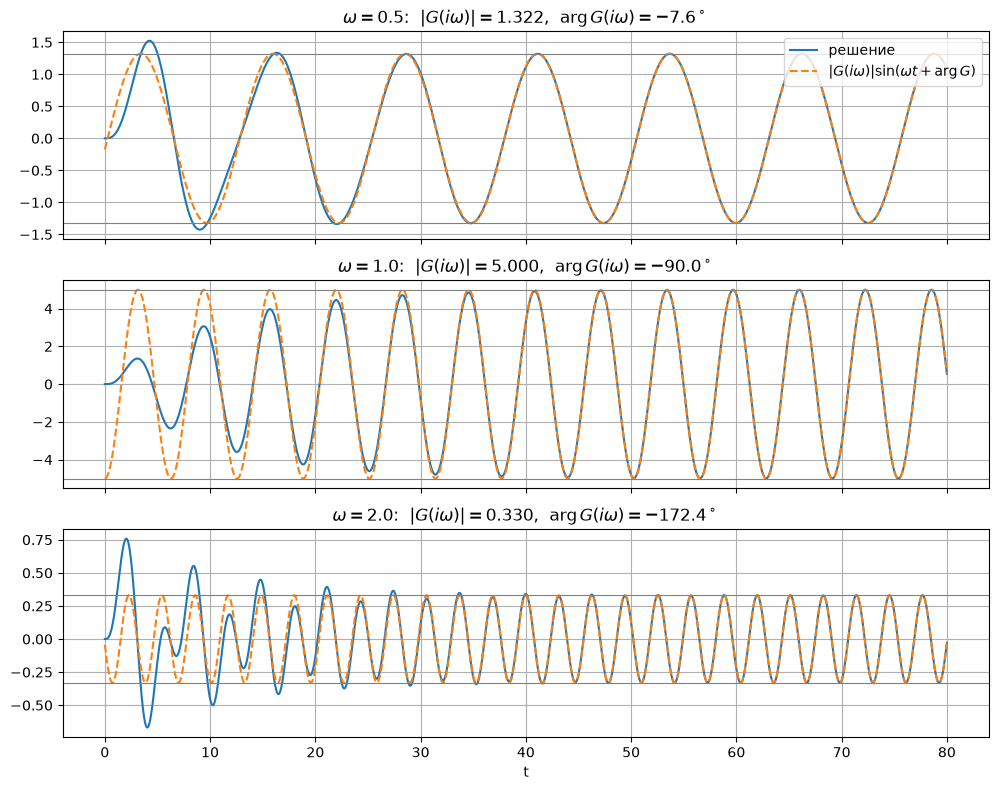

In [2]:
T = np.linspace(0, 80, 8001)
freqs = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, w in zip(axes, freqs):
    t, x = ct.forced_response(G, T=T, U=np.sin(w * T))
    Gw = G(1j * w)                         # значение передаточной функции при s = i*w
    A, psi = abs(Gw), np.angle(Gw)
    ax.plot(t, x, label='решение')
    ax.plot(t, A * np.sin(w * t + psi), '--', label=r'$|G(i\omega)|\sin(\omega t + \arg G)$')
    ax.axhline(A, color='gray', lw=0.8)
    ax.axhline(-A, color='gray', lw=0.8)
    ax.set_title(rf'$\omega = {w}$:  $|G(i\omega)| = {A:.3f}$,  $\arg G(i\omega) = {np.degrees(psi):.1f}^\circ$')
    ax.grid(True)
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('t')
plt.tight_layout()
plt.savefig('freq_example_time.png', dpi=120)
plt.show()

В начале движения видны биения — наложение затухающих свободных колебаний с частотой $\approx\omega_0$ и вынужденных. Свободные колебания затухают как $e^{-\zeta\omega_0 t}$, после чего решение совпадает с предсказанным. В резонансе ($\omega = \omega_0$) амплитуда в $1/(2\zeta) = 5$ раз больше статического отклонения, а сдвиг фазы равен $-90^\circ$.

Проверим совпадение амплитуды на установившемся участке:

In [3]:
for w in freqs:
    t, x = ct.forced_response(G, T=T, U=np.sin(w * T))
    tail = t > 60
    measured = (x[tail].max() - x[tail].min()) / 2
    print(f'omega = {w}: |G(i omega)| = {abs(G(1j * w)):.3f},  амплитуда решения = {measured:.3f}')

omega = 0.5: |G(i omega)| = 1.322,  амплитуда решения = 1.322
omega = 1.0: |G(i omega)| = 5.000,  амплитуда решения = 4.998
omega = 2.0: |G(i omega)| = 0.330,  амплитуда решения = 0.331


## Амплитудно- и фазочастотная характеристики

Зависимости $|G(i\omega)|$ и $\arg G(i\omega)$ от частоты вычисляет функция `ct.frequency_response`. Точки на графиках соответствуют трём частотам, для которых решение построено выше.

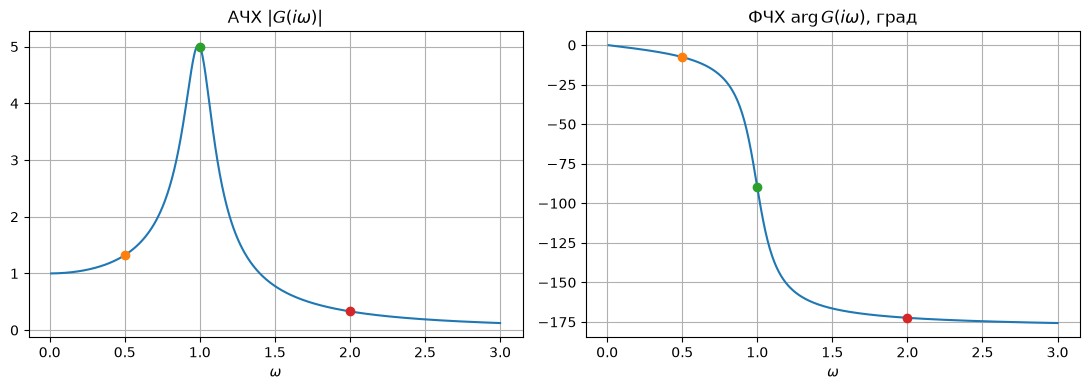

In [4]:
w = np.linspace(0.01, 3, 600)
fr = ct.frequency_response(G, w)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(w, fr.magnitude)
axes[1].plot(w, np.degrees(fr.phase))
for wk in freqs:
    Gk = G(1j * wk)
    axes[0].plot(wk, abs(Gk), 'o')
    axes[1].plot(wk, np.degrees(np.angle(Gk)), 'o')
axes[0].set_title(r'АЧХ $|G(i\omega)|$')
axes[1].set_title(r'ФЧХ $\arg G(i\omega)$, град')
for ax in axes:
    ax.set_xlabel(r'$\omega$')
    ax.grid(True)
plt.tight_layout()
plt.savefig('freq_example_afc.png', dpi=120)
plt.show()

**Что попробовать:**
- уменьшите $\zeta$ до 0.02: как изменятся резонансный пик и продолжительность переходного процесса?
- постройте те же характеристики в логарифмическом масштабе функцией `ct.bode_plot(G)`;
- подайте на вход сумму двух гармоник разной частоты: убедитесь, что установившийся отклик — сумма откликов на каждую из них (линейность).